<h3>Exploring Neural Networks Learn Different Step Functions</h3>
<ul>
<li><p>Step functions are hard to learn to a Neural networks due to its Non-linear and discontinuous nature.</p></li>
 <li><p>Now let us try to make neural networks learn different step functions with some Hyperparameter Tuning.</p></li>
 <li><p>By this we can understand that Neural Networks are some what limited in learnability</p></li>
 </ul>

<h3>Threshold Function</h3>
<li><p>Thresold function is a step functionthat switch between two values (usually 0 and 1) when the input reaches a threshold (&#952).</p></li>
<img src="threshold_function.png" alternative="Thresold Function" style="height:300px;width:200px:">
<br>
<br>
<li><p>Heavy-side Function is a thresold function with threshold function</p></li>
<img src="heaviside_step_function.png" alternative="Heaviside Function" style="height:300px;width:200px:">

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Step 1: Data
X = np.array([[-2], [-1], [-0.5], [0], [0.5], [1], [2]])
y = np.array([[0], [0], [0], [1], [1], [1], [1]]) #heaviside_function

# Step 2: Model
model = keras.Sequential([
    keras.layers.Dense(5, activation='relu', input_shape=(1,)),
    keras.layers.Dense(1, activation='sigmoid')
])

# Step 3: Compile
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 4: Train
model.fit(X, y, epochs=200, verbose=0)

# Step 5: Test
test = np.array([[-1.5], [-0.2], [0.2], [1.5],[1]])
predictions = model.predict(test)

print(predictions)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
[[0.26840678]
 [0.5062593 ]
 [0.64566696]
 [0.8402895 ]
 [0.77784   ]]


<p>That was fun :) , now let us try with some bigger dataset

In [1]:
#Data set generator for threshold function (default: heaviside)
import numpy as np

def generate_dataset(n=1000,threshold=0):
    # Generate random inputs between -5 and 5
    X = np.random.uniform(-5+threshold, 5+threshold, n)
    
    # Apply step function
    y = (X >= threshold).astype(int)
    
    # Reshape for neural network
    return X.reshape(-1, 1), y.reshape(-1, 1)

In [2]:
#splitting data
from sklearn.model_selection import train_test_split

# Generate data

threshold = int(input("enter the threshold:"))
X, y = generate_dataset(3000,threshold)

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13
)

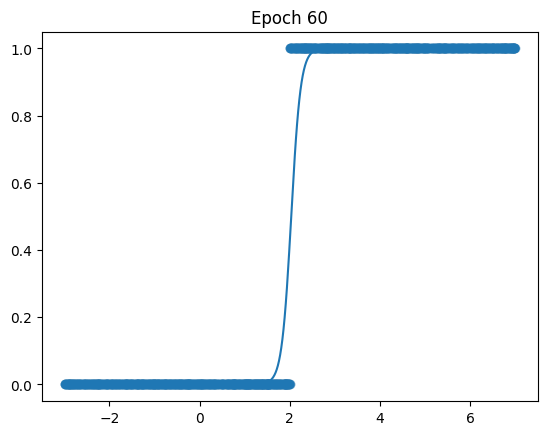

In [3]:
#core model
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from IPython.display import clear_output

model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(1,)),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
# history = model.fit(
#     X_train, y_train,
#     epochs=50,
#     validation_data=(X_test, y_test),
#     verbose=1
# )
X_plot = np.linspace(-5+threshold, 5+threshold, 400).reshape(-1, 1)

# plt.ion()  # interactive mode ON
# fig, ax = plt.subplots()

# Step 4: Training with live plotting
epochs = 60

for epoch in range(epochs):
    model.fit(X, y, epochs=1, verbose=1)

    y_pred = model.predict(X_plot, verbose=0)

    clear_output(wait=True)  # 🔥 important

    plt.figure()
    plt.scatter(X, y, alpha=0.2)
    plt.plot(X_plot, y_pred)

    plt.title(f"Epoch {epoch+1}")
    plt.show()

In [4]:
#Evaluate model
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9967 - loss: 0.0152
Test Accuracy: 0.9967


Model evaluator considers the value >0.5 as 1 and <0.5 as 0 thats why we getting that much good accuracy.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


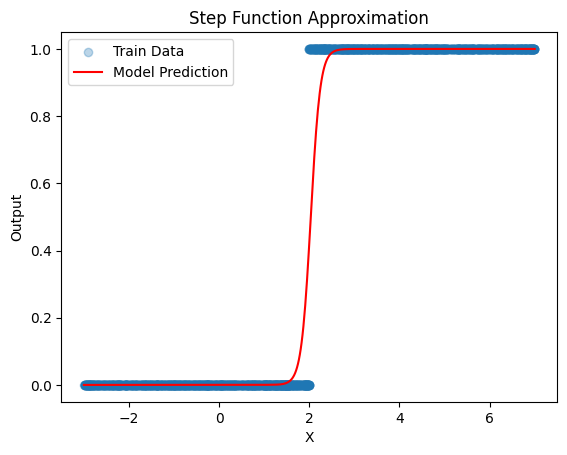

In [5]:
#import matplotlib.pyplot as plt

# Generate smooth inputs for plotting
X_plot = np.linspace(-5+threshold, 5+threshold, 500).reshape(-1, 1)
y_pred = model.predict(X_plot)

plt.scatter(X_train, y_train, label="Train Data", alpha=0.3)
plt.plot(X_plot, y_pred, color='red', label="Model Prediction")

plt.title("Step Function Approximation")
plt.xlabel("X")
plt.ylabel("Output")
plt.legend()
plt.show()

<li>So after all that we can say that the learnability of neural networks is not really limited if we do some hyperparameter tuning.</li>
<li>Why be so quick to conclude , let us try some discontinuous , non linear stepped function and this is the right time to check with floor function</li>
<li>now let us try to make a neural network learn floor function , same as previous , give a function to generate dataset , split , train model , visualise training(in vs code-colab) , test accuracy and plot a final graph</li>

<h5>Floor Function</h5>
<img src = "floor_func.png",alternative="Floor Function" style="height:350px;width:250px:">

In [6]:
#dataset generator
import numpy as np

def generate_floor_dataset(n=1000):
    X = np.random.uniform(-5, 5, n)
    y = np.floor(X)  # floor function
    
    return X.reshape(-1, 1), y.reshape(-1, 1)

In [7]:
#splitting the data
from sklearn.model_selection import train_test_split

X, y = generate_floor_dataset(3000)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

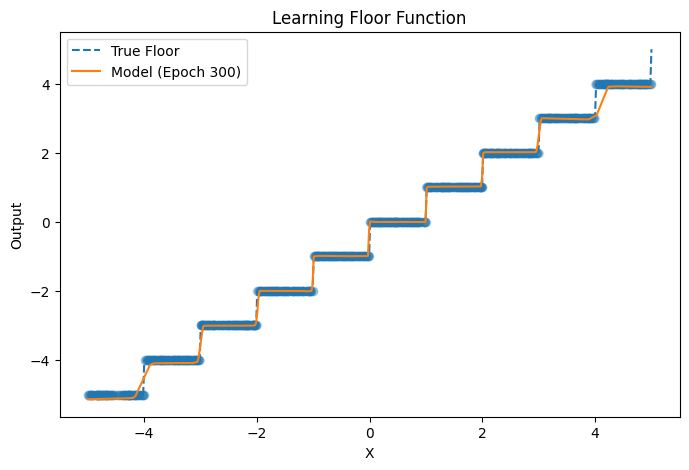

In [8]:
#the core model

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from IPython.display import clear_output

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(1,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(1)  # linear output (regression)
])

model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

X_plot = np.linspace(-5, 5, 500).reshape(-1, 1)

epochs = 300

for epoch in range(epochs):
    model.fit(X_train, y_train, epochs=1, verbose=1)

    y_pred = model.predict(X_plot, verbose=0)

    clear_output(wait=True)

    plt.figure(figsize=(8,5))
    
    # True function
    plt.plot(X_plot, np.floor(X_plot), label="True Floor", linestyle='dashed')
    
    # Model prediction
    plt.plot(X_plot, y_pred, label=f"Model (Epoch {epoch+1})")
    
    plt.scatter(X_train, y_train, alpha=0.1)
    
    plt.title("Learning Floor Function")
    plt.xlabel("X")
    plt.ylabel("Output")
    plt.legend()
    plt.show()

In [9]:
#Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0617 - mae: 0.0617
Test MAE: 0.0617


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


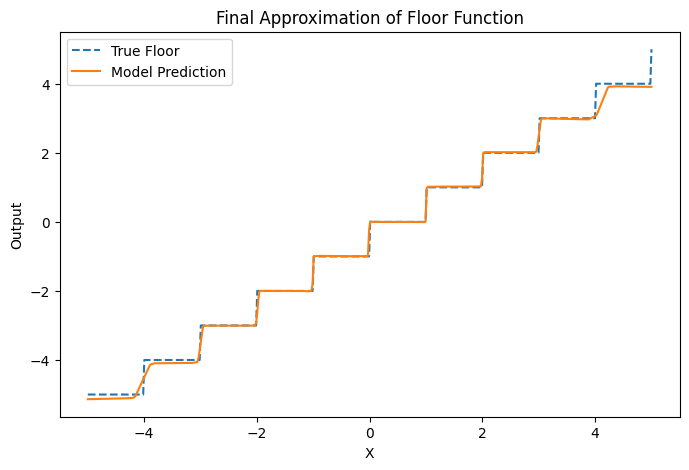

In [10]:
y_pred_final = model.predict(X_plot)

plt.figure(figsize=(8,5))

plt.plot(X_plot, np.floor(X_plot), label="True Floor", linestyle='dashed')
plt.plot(X_plot, y_pred_final, label="Model Prediction")

plt.title("Final Approximation of Floor Function")
plt.xlabel("X")
plt.ylabel("Output")
plt.legend()
plt.show()

In [11]:
model.predict(np.array([4.56,5.56,6.79]).reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


array([[3.9188533],
       [3.917914 ],
       [4.1531515]], dtype=float32)

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,845 (390.02 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 66,564 (260.02 KB)

<li>It went quite tuff and learned the function but at what cost :(</li>
<li>99,845 parameters to learn a simple floor function is definitely a step back </li>
<li>The discontinuous points are not differentiable though</li>